# Chatbot de Atendimento a Trouble Tickets com Análise de Sentimento via Redes Neurais

**1. Contexto de Negócio**

Uma central de suporte técnico e NOC (Network Operations Center) atende clientes corporativos que reportam incidentes e falhas em serviços críticos de rede e TI (links MPLS, sessões BGP, roteadores core, firewalls e conexões VPN).

**Objetivos do Chatbot:**
1. **Identificação e Consulta do Chamado:** Iniciar a interação solicitando o número do **Trouble Ticket** e consultar imediatamente seu último status na base operacional (**Aberto**, **Fechado**, **Aguardando cliente** ou **Tratativa em andamento**).
2. **Pergunta de Continuidade:** Apresentar o status e detalhes do ticket e perguntar se o cliente deseja algo mais ou tem alguma observação.
3. **Análise de Sentimentos das Interações Adicionais:** Caso o cliente envie mensagens adicionais (reclamações de demora, agradecimentos ou dúvidas técnicas), analisar o sentimento do cliente em tempo real utilizando uma **Rede Neural** (`MLPClassifier` com representação vetorial `TF-IDF`).
4. **Respostas Inteligentes e Escalonamento:**
   - **Sentimento Negativo:** Acionar alerta de prioridade e escalonamento para o NOC Nível 2.
   - **Sentimento Positivo:** Registrar satisfação e agradecer a parceria.
   - **Sentimento Neutro:** Anexar a observação técnica ao histórico do ticket.
5. **Auditoria e Registro em Arquivo:** Gravar cada interação (com timestamp, número do ticket consultado, status, mensagem do cliente, emoção/sentimento analisado e score de confiança) no arquivo **`registro_sentimentos_tickets.csv`**.

**0. Importação de Dependências**

Carregamos as bibliotecas necessárias para manipulação de dados (`pandas`, `numpy`), processamento de linguagem natural e redes neurais (`scikit-learn`), visualização (`matplotlib`) e auditoria de arquivos.

In [1]:
import os
import random
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


**2. Geração de Dados Sintéticos: Base de Trouble Tickets**

Criamos uma tabela simulando o banco de dados operacional de chamados de redes/telecom. Cada chamado possui os campos:
- `ticket_id`: Identificador único do chamado (ex: `TK-1001`, `TK-1002`, ...);
- `cliente`: Razão social da empresa cliente;
- `servico_afetado`: Serviço de rede/TI envolvido;
- `ultimo_status`: Um dos 4 status solicitados (**Aberto**, **Fechado**, **Aguardando cliente**, **Tratativa em andamento**);
- `data_abertura`: Data e hora da abertura do chamado;
- `detalhes`: Histórico resumido da última atuação técnica.

In [2]:
tickets_data = [
    {
        "ticket_id": "TK-1001",
        "cliente": "Banco Alfa S/A",
        "servico_afetado": "Link MPLS Dedicado - Matriz",
        "ultimo_status": "Tratativa em andamento",
        "data_abertura": "2026-08-23 09:15",
        "detalhes": "Equipe de campo acionada para troca de porta óptica no switch de distribuição."
    },
    {
        "ticket_id": "TK-1002",
        "cliente": "Varejo Global Logística",
        "servico_afetado": "Roteador Core BGP - Filial Campinas",
        "ultimo_status": "Fechado",
        "data_abertura": "2026-08-22 14:30",
        "detalhes": "Sessão BGP restabelecida após normalização de operadora parceira. Testes concluídos com sucesso."
    },
    {
        "ticket_id": "TK-1003",
        "cliente": "Hospital São Lucas",
        "servico_afetado": "Conexão VPN IPsec Site-to-Site",
        "ultimo_status": "Aguardando cliente",
        "data_abertura": "2026-08-23 11:00",
        "detalhes": "Aguardando teste de ping do cliente e validação da chave pré-compartilhada (PSK)."
    },
    {
        "ticket_id": "TK-1004",
        "cliente": "Indústria MetalTech",
        "servico_afetado": "Firewall Principal - Cluster HA",
        "ultimo_status": "Aberto",
        "data_abertura": "2026-08-23 16:45",
        "detalhes": "Chamado aberto via monitoramento automático de CPU acima de 95%."
    },
    {
        "ticket_id": "TK-1005",
        "cliente": "E-commerce Brasil",
        "servico_afetado": "Link de Internet Redundante",
        "ultimo_status": "Tratativa em andamento",
        "data_abertura": "2026-08-23 13:20",
        "detalhes": "Análise de perda de pacotes e latência intermitente pela equipe de NOC N2."
    },
    {
        "ticket_id": "TK-1006",
        "cliente": "TechFin Soluções",
        "servico_afetado": "Servidor DNS Primário",
        "ultimo_status": "Fechado",
        "data_abertura": "2026-08-21 08:00",
        "detalhes": "Configuração de zona DNS corrigida e sincronizada com servidores secundários."
    },
    {
        "ticket_id": "TK-1007",
        "cliente": "AgroExport Alimentos",
        "servico_afetado": "Circuito Satelital Filial MT",
        "ultimo_status": "Aguardando cliente",
        "data_abertura": "2026-08-22 17:10",
        "detalhes": "Solicitado reinício do modem satelital local pelo responsável técnico da unidade."
    },
    {
        "ticket_id": "TK-1008",
        "cliente": "Consultoria Prime",
        "servico_afetado": "Acesso Remoto VPN SSL",
        "ultimo_status": "Aberto",
        "data_abertura": "2026-08-23 17:30",
        "detalhes": "Usuários relatando lentidão na autenticação de dois fatores."
    }
]

df_tickets = pd.DataFrame(tickets_data)
print(f"Total de Trouble Tickets cadastrados na base: {len(df_tickets)}")
print("\nDistribuição por Último Status:")
print(df_tickets["ultimo_status"].value_counts())
df_tickets

Total de Trouble Tickets cadastrados na base: 8

Distribuição por Último Status:
ultimo_status
Tratativa em andamento    2
Fechado                   2
Aguardando cliente        2
Aberto                    2
Name: count, dtype: int64


,ticket_id,cliente,servico_afetado,ultimo_status,data_abertura,detalhes
0,TK-1001,Banco Alfa S/A,Link MPLS Dedicado - Matriz,Tratativa em andamento,2026-08-23 09:15,Equipe de campo acionada para troca de porta ó...
1,TK-1002,Varejo Global Logística,Roteador Core BGP - Filial Campinas,Fechado,2026-08-22 14:30,Sessão BGP restabelecida após normalização de ...
2,TK-1003,Hospital São Lucas,Conexão VPN IPsec Site-to-Site,Aguardando cliente,2026-08-23 11:00,Aguardando teste de ping do cliente e validaçã...
3,TK-1004,Indústria MetalTech,Firewall Principal - Cluster HA,Aberto,2026-08-23 16:45,Chamado aberto via monitoramento automático de...
4,TK-1005,E-commerce Brasil,Link de Internet Redundante,Tratativa em andamento,2026-08-23 13:20,Análise de perda de pacotes e latência intermi...
5,TK-1006,TechFin Soluções,Servidor DNS Primário,Fechado,2026-08-21 08:00,Configuração de zona DNS corrigida e sincroniz...
6,TK-1007,AgroExport Alimentos,Circuito Satelital Filial MT,Aguardando cliente,2026-08-22 17:10,Solicitado reinício do modem satelital local p...
7,TK-1008,Consultoria Prime,Acesso Remoto VPN SSL,Aberto,2026-08-23 17:30,Usuários relatando lentidão na autenticação de...


**3. Geração de Dados Sintéticos: Corpus de Treinamento de Sentimento**

Para treinar a Rede Neural responsável por classificar as mensagens adicionais dos clientes, geramos um corpus sintético balanceado com frases de contexto técnico de suporte:
- **`negativo`**: Reclamações de SLA, indisponibilidade prolongada, lentidão grave, indignação.
- **`positivo`**: Elogios à resolução rápida, agradecimentos ao suporte, link restabelecido.
- **`neutro`**: Dúvidas técnicas sobre IP, agendamento de janela, procedimentos e configurações.

In [3]:
frases_negativas_tickets = [
    "o link continua fora do ar e a empresa está parada",
    "estou muito insatisfeito com a demora no atendimento",
    "já faz horas que abri o chamado e ninguém resolveu",
    "o atendente não soube explicar o motivo da queda",
    "o problema voltou a acontecer pela terceira vez essa semana",
    "péssimo suporte técnico estamos com prejuízo na operação",
    "o sla de atendimento foi completamente estourado",
    "ninguém do noc entrou em contato até agora",
    "estou muito decepcionado com a estabilidade do link",
    "o roteador travou de novo e estamos sem comunicação",
    "vou cancelar o contrato se não resolverem isso hoje",
    "fiquei esperando horas no telefone e não tive retorno",
    "não gostei do atendimento que recebi do suporte técnico",
    "a lentidão na rede continua insuportável",
    "achei péssimo o serviço não recomendo para ninguém",
    "não foi uma boa tratativa infelizmente o problema persiste",
]

frases_positivas_tickets = [
    "o atendimento do noc foi excelente e rápido",
    "muito obrigado o link já foi restabelecido com sucesso",
    "a equipe técnica foi muito atenciosa e resolveu na hora",
    "parabéns pela agilidade na troca do equipamento",
    "fiquei muito satisfeito com a solução do problema",
    "o suporte técnico foi perfeito tudo voltou a funcionar",
    "recomendo muito o trabalho da equipe de redes",
    "tudo normalizado por aqui excelente trabalho",
    "atendimento rápido eficiente e muito profissional",
    "estou muito feliz com o retorno ágil da equipe",
    "não tenho nada a reclamar suporte de altíssima qualidade",
    "resolveram a rota bgp em poucos minutos parabéns",
    "não imaginava que seria tão rápido o conserto adorei",
    "nada a reclamar atendimento perfeito do plantão",
    "o técnico de campo foi super ágil e prestativo",
    "não é exagero dizer que o suporte foi nota dez",
]

frases_neutras_tickets = [
    "gostaria de saber qual o ip de gateway configurado",
    "qual é a previsão de término da manutenção programada",
    "preciso alterar o e-mail de notificação do monitoramento",
    "como faço para solicitar um relatório de tráfego mrg",
    "qual o procedimento para agendar uma janela de manutenção",
    "gostaria de saber os horários do plantão nível dois",
    "preciso atualizar o contato do responsável técnico local",
    "qual o asn configurado na sessão bgp",
    "vocês podem enviar o log do roteador por e-mail",
    "gostaria de mais informações sobre o link redundante",
    "qual o prazo padrão de atendimento para este tipo de falha",
    "como faço para abrir um chamado para outra filial",
]

sujeitos = ["", "sinceramente, ", "olha, ", "na real, ", "por favor, ", "informo que ", "comunicamos que "]
complementos = [
    "", " novamente", " hoje", " com urgência", " no nosso circuito principal",
    " na filial matriz", " com a equipe de redes", " no link dedicado"
]

def gerar_variacoes_suporte(base_list, n_exemplos, rng):
    exemplos = []
    while len(exemplos) < n_exemplos:
        base = rng.choice(base_list)
        prefixo = rng.choice(sujeitos)
        sufixo = rng.choice(complementos)
        frase = (prefixo + base + sufixo).strip()
        frase = frase[0].upper() + frase[1:] + "."
        exemplos.append(frase)
    return exemplos

rng = random.Random(RANDOM_STATE)
n_por_classe = 120

negativas = gerar_variacoes_suporte(frases_negativas_tickets, n_por_classe, rng)
positivas = gerar_variacoes_suporte(frases_positivas_tickets, n_por_classe, rng)
neutras = gerar_variacoes_suporte(frases_neutras_tickets, n_por_classe, rng)

textos = negativas + positivas + neutras
rotulos = (["negativo"] * len(negativas) +
           ["positivo"] * len(positivas) +
           ["neutro"] * len(neutras))

df_sentimento = pd.DataFrame({"texto": textos, "sentimento": rotulos})
df_sentimento = df_sentimento.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Total de mensagens de treinamento: {len(df_sentimento)}")
print(df_sentimento["sentimento"].value_counts())
df_sentimento.head(10)

Total de mensagens de treinamento: 360
sentimento
positivo    120
negativo    120
neutro      120
Name: count, dtype: int64


,texto,sentimento
0,"Olha, não imaginava que seria tão rápido o con...",positivo
1,Vou cancelar o contrato se não resolverem isso...,negativo
2,"Por favor, qual o procedimento para agendar um...",neutro
3,Gostaria de saber os horários do plantão nível...,neutro
4,"Por favor, o sla de atendimento foi completame...",negativo
5,"Por favor, como faço para abrir um chamado par...",neutro
6,Não gostei do atendimento que recebi do suport...,negativo
7,"Na real, o roteador travou de novo e estamos s...",negativo
8,"Por favor, como faço para abrir um chamado par...",neutro
9,"Na real, o suporte técnico foi perfeito tudo v...",positivo


**4. Vetorização TF-IDF e Treinamento da Rede Neural (`MLPClassifier`)**

Separamos 75% dos dados para treino e 25% para teste estratificado. Vetorizamos as mensagens com unigramas e bigramas ponderados via `TfidfVectorizer(ngram_range=(1, 2))` e treinamos o `MLPClassifier` com uma camada oculta de 32 neurônios.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df_sentimento["texto"], df_sentimento["sentimento"],
    test_size=0.25, random_state=RANDOM_STATE, stratify=df_sentimento["sentimento"]
)

vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation="relu",
    max_iter=500,
    random_state=RANDOM_STATE
)
mlp.fit(X_train_vec, y_train)

y_pred_mlp = mlp.predict(X_test_vec)
acc_mlp = accuracy_score(y_test, y_pred_mlp)

print(f"Acurácia da Rede Neural (TF-IDF + MLP): {acc_mlp:.4f} ({acc_mlp*100:.1f}%)")
print("\nRelatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred_mlp))

Acurácia da Rede Neural (TF-IDF + MLP): 0.9889 (98.9%)

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

    negativo       1.00      0.97      0.98        30
      neutro       1.00      1.00      1.00        30
    positivo       0.97      1.00      0.98        30

    accuracy                           0.99        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.99      0.99      0.99        90



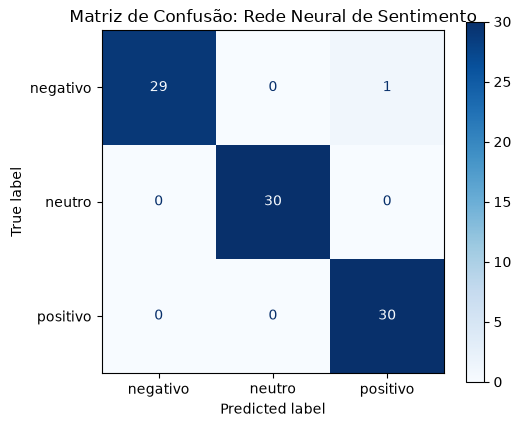

In [5]:
labels_ordenados = ["negativo", "neutro", "positivo"]
cm = confusion_matrix(y_test, y_pred_mlp, labels=labels_ordenados)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp = ConfusionMatrixDisplay(cm, display_labels=labels_ordenados)
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Matriz de Confusão: Rede Neural de Sentimento")
plt.tight_layout()
plt.show()

**5. Implementação do Fluxo Conversacional e Registro em Arquivo**

Implementamos os métodos centrais:
- `consultar_ticket`: Busca flexível por ID (aceita `TK-1001`, `tk-1001` ou `1001`);
- `classificar_sentimento_texto`: Executa predição via Rede Neural e calcula o grau de confiança;
- `registrar_em_arquivo_csv`: Grava o log estruturado em **`registro_sentimentos_tickets.csv`** com:
  - `data_hora`: timestamp da interação;
  - `ticket_id`: número do trouble ticket consultado;
  - `ultimo_status`: status do chamado no momento da consulta;
  - `mensagem_cliente`: mensagem digitada pelo cliente;
  - `sentimento_analisado`: emoção classificada (`positivo`, `negativo`, `neutro`);
  - `score_confianca`: probabilidade da classe prevista;
- `executar_fluxo_chatbot`: Orquestra todo o diálogo, respostas do bot e escalonamento para o NOC.

In [6]:
LOG_ARQUIVO_CSV = "registro_sentimentos_tickets.csv"

def consultar_ticket(ticket_id_input, df_base_tickets):
    """Normaliza o identificador e busca o chamado na base de dados."""
    if not isinstance(ticket_id_input, str):
        ticket_id_input = str(ticket_id_input)
    
    clean_id = ticket_id_input.strip().upper()
    if not clean_id.startswith("TK-"):
        if clean_id.startswith("TK"):
            clean_id = "TK-" + clean_id[2:].strip("-")
        else:
            clean_id = f"TK-{clean_id}"
            
    match = df_base_tickets[df_base_tickets["ticket_id"] == clean_id]
    if not match.empty:
        return match.iloc[0].to_dict()
    return None

def classificar_sentimento_texto(texto, vectorizer_model, mlp_model):
    """Analisa o sentimento do texto usando o modelo MLP treinado."""
    vec = vectorizer_model.transform([texto])
    pred = mlp_model.predict(vec)[0]
    probs = mlp_model.predict_proba(vec)[0]
    classes = list(mlp_model.classes_)
    confianca = probs[classes.index(pred)]
    return pred, confianca

def registrar_em_arquivo_csv(ticket_id, status_ticket, mensagem_cliente, sentimento, confianca, caminho_csv=LOG_ARQUIVO_CSV):
    """Registra a consulta e análise de sentimento no arquivo CSV de auditoria."""
    novo_registro = pd.DataFrame([{
        "data_hora": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "ticket_id": ticket_id,
        "ultimo_status": status_ticket,
        "mensagem_cliente": mensagem_cliente,
        "sentimento_analisado": sentimento,
        "score_confianca": round(confianca, 4)
    }])
    
    if not os.path.exists(caminho_csv):
        novo_registro.to_csv(caminho_csv, index=False, encoding="utf-8-sig")
    else:
        novo_registro.to_csv(caminho_csv, mode="a", header=False, index=False, encoding="utf-8-sig")

def executar_fluxo_chatbot(ticket_id_input, mensagem_adicional=None, df_base_tickets=df_tickets, vectorizer_model=vectorizer, mlp_model=mlp, caminho_log=LOG_ARQUIVO_CSV):
    """
    Executa o fluxo do Chatbot:
    1. Solicita e consulta o Trouble Ticket.
    2. Exibe o último status (Aberto, Fechado, Aguardando cliente, Tratativa em andamento).
    3. Pergunta se deseja algo mais.
    4. Se houver interação adicional, analisa o sentimento via Rede Neural e salva em arquivo.
    """
    print("=" * 75)
    print("🤖 BOT: Olá! Bem-vindo ao Autoatendimento de Suporte Técnico & NOC.")
    print(f"👤 CLIENTE: [Informa o Ticket]: {ticket_id_input}")
    
    info_ticket = consultar_ticket(ticket_id_input, df_base_tickets)
    
    if not info_ticket:
        print(f"🤖 BOT: ❌ Não localizamos o Trouble Ticket '{ticket_id_input}' em nossa base ativa.")
        print("🤖 BOT: Por favor, confira o número do ticket ou entre em contato com o NOC Central.")
        print("=" * 75 + "\n")
        return None
    
    # Exibe informações do ticket
    t_id = info_ticket["ticket_id"]
    status = info_ticket["ultimo_status"]
    cliente = info_ticket["cliente"]
    servico = info_ticket["servico_afetado"]
    detalhes = info_ticket["detalhes"]
    
    print(f"🤖 BOT: ✅ Ticket {t_id} localizado com sucesso!")
    print(f"   • Cliente: {cliente}")
    print(f"   • Serviço Afetado: {servico}")
    print(f"   • ÚLTIMO STATUS: [{status.upper()}]")
    print(f"   • Detalhes da Tratativa: {detalhes}")
    print("-" * 75)
    print("🤖 BOT: Deseja algo mais ou tem alguma observação sobre este ticket?")
    
    if mensagem_adicional and mensagem_adicional.strip():
        print(f"👤 CLIENTE: \"{mensagem_adicional}\"")
        
        # Análise de sentimento via Rede Neural
        sentimento, confianca = classificar_sentimento_texto(mensagem_adicional, vectorizer_model, mlp_model)
        
        # Resposta contextualizada
        if sentimento == "negativo":
            resposta_bot = (
                f"🤖 BOT: Sentimos muito pelo transtorno! Identificamos criticidade na sua mensagem "
                f"(Sentimento: {sentimento.upper()} | Confiança: {confianca*100:.1f}%).\n"
                f"       🚨 Já registramos um alerta prioritário de ESCALONAMENTO para o NOC Nível 2 "
                f"agilizar a tratativa do seu chamado."
            )
        elif sentimento == "positivo":
            resposta_bot = (
                f"🤖 BOT: Ficamos muito felizes com seu retorno positivo! "
                f"(Sentimento: {sentimento.upper()} | Confiança: {confianca*100:.1f}%).\n"
                f"       Agradecemos a confiança no suporte técnico. Conte sempre com a nossa equipe!"
            )
        else: # neutro
            resposta_bot = (
                f"🤖 BOT: Anotamos sua observação operacional "
                f"(Sentimento: {sentimento.upper()} | Confiança: {confianca*100:.1f}%).\n"
                f"       Sua solicitação foi anexada ao histórico do chamado {t_id}."
            )
        
        print(resposta_bot)
        
        # Gravação no arquivo CSV
        registrar_em_arquivo_csv(t_id, status, mensagem_adicional, sentimento, confianca, caminho_log)
        print(f"\n📁 [LOG AUDITORIA]: Interação gravada com sucesso em '{caminho_log}' (Ticket: {t_id} | Emoção: {sentimento})")
    else:
        print("👤 CLIENTE: [Sem mensagens adicionais / Encerramento]")
        print("🤖 BOT: Perfeito! Obrigado por entrar em contato. Atendimento finalizado.")
    
    print("=" * 75 + "\n")

**6. Simulação de Atendimentos com Casos Reais**

Executamos o chatbot para os diferentes status de chamados e diferentes comportamentos de clientes:
1. **Cenário 1**: `TK-1001` (*Tratativa em andamento*) $\rightarrow$ Reclamação grave de lentidão/parada (Sentimento **Negativo** $\rightarrow$ Escalonamento NOC);
2. **Cenário 2**: `TK-1002` (*Fechado*) $\rightarrow$ Elogio e agradecimento (Sentimento **Positivo**);
3. **Cenário 3**: `TK-1003` (*Aguardando cliente*) $\rightarrow$ Dúvida técnica operacional sobre IP (Sentimento **Neutro**);
4. **Cenário 4**: `TK-1004` (*Aberto*) $\rightarrow$ Cliente apenas verifica o status e encerra sem mensagem adicional;
5. **Cenário 5**: `TK-9999` $\rightarrow$ Ticket não localizado na base.

In [7]:
# Remove arquivo anterior para gerar log limpo na execução
if os.path.exists(LOG_ARQUIVO_CSV):
    os.remove(LOG_ARQUIVO_CSV)

print("INICIANDO SIMULAÇÃO DE ATENDIMENTOS DO CHATBOT:\n")

# Cenário 1: Tratativa em andamento + Reclamação
executar_fluxo_chatbot(
    ticket_id_input="TK-1001",
    mensagem_adicional="Já faz horas que estamos com o link parado e com prejuízo na operação, preciso de urgência!"
)

# Cenário 2: Fechado + Elogio
executar_fluxo_chatbot(
    ticket_id_input="1002",
    mensagem_adicional="Muito obrigado pelo suporte, a equipe técnica foi excelente e resolveu na hora!"
)

# Cenário 3: Aguardando cliente + Dúvida operacional
executar_fluxo_chatbot(
    ticket_id_input="tk-1003",
    mensagem_adicional="Gostaria de saber qual o IP de gateway configurado para eu testar a rota aqui."
)

# Cenário 4: Aberto + Sem interação adicional
executar_fluxo_chatbot(
    ticket_id_input="TK-1004",
    mensagem_adicional=None
)

# Cenário 5: Ticket Inexistente
executar_fluxo_chatbot(
    ticket_id_input="TK-9999",
    mensagem_adicional="Alguém pode me ajudar?"
)

INICIANDO SIMULAÇÃO DE ATENDIMENTOS DO CHATBOT:

🤖 BOT: Olá! Bem-vindo ao Autoatendimento de Suporte Técnico & NOC.
👤 CLIENTE: [Informa o Ticket]: TK-1001
🤖 BOT: ✅ Ticket TK-1001 localizado com sucesso!
   • Cliente: Banco Alfa S/A
   • Serviço Afetado: Link MPLS Dedicado - Matriz
   • ÚLTIMO STATUS: [TRATATIVA EM ANDAMENTO]
   • Detalhes da Tratativa: Equipe de campo acionada para troca de porta óptica no switch de distribuição.
---------------------------------------------------------------------------
🤖 BOT: Deseja algo mais ou tem alguma observação sobre este ticket?
👤 CLIENTE: "Já faz horas que estamos com o link parado e com prejuízo na operação, preciso de urgência!"
🤖 BOT: Sentimos muito pelo transtorno! Identificamos criticidade na sua mensagem (Sentimento: NEGATIVO | Confiança: 99.3%).
       🚨 Já registramos um alerta prioritário de ESCALONAMENTO para o NOC Nível 2 agilizar a tratativa do seu chamado.

📁 [LOG AUDITORIA]: Interação gravada com sucesso em 'registro_sentimentos

**7. Visualização e Auditoria do Arquivo Gerado (`registro_sentimentos_tickets.csv`)**

Lemos o arquivo CSV persistido em disco para auditar o número do trouble ticket consultado e a emoção analisada.

In [8]:
df_log = pd.read_csv(LOG_ARQUIVO_CSV)
print(f"Total de interações gravadas no arquivo '{LOG_ARQUIVO_CSV}': {len(df_log)}\n")
df_log

Total de interações gravadas no arquivo 'registro_sentimentos_tickets.csv': 3



,data_hora,ticket_id,ultimo_status,mensagem_cliente,sentimento_analisado,score_confianca
0,2026-08-23 18:28:01,TK-1001,Tratativa em andamento,Já faz horas que estamos com o link parado e c...,negativo,0.9926
1,2026-08-23 18:28:01,TK-1002,Fechado,"Muito obrigado pelo suporte, a equipe técnica ...",positivo,0.9861
2,2026-08-23 18:28:01,TK-1003,Aguardando cliente,Gostaria de saber qual o IP de gateway configu...,neutro,0.9830


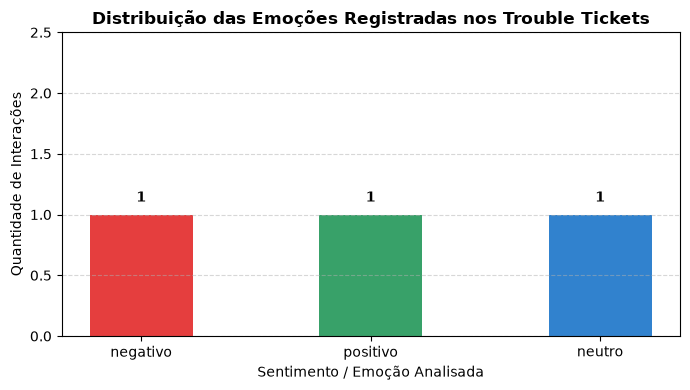

In [9]:
plt.figure(figsize=(7, 4))
contagem_sentimentos = df_log["sentimento_analisado"].value_counts()
cores = {"negativo": "#e53e3e", "positivo": "#38a169", "neutro": "#3182ce"}
cores_grafico = [cores.get(s, "#718096") for s in contagem_sentimentos.index]

bars = plt.bar(contagem_sentimentos.index, contagem_sentimentos.values, color=cores_grafico, width=0.45)
plt.title("Distribuição das Emoções Registradas nos Trouble Tickets", fontsize=12, fontweight="bold")
plt.xlabel("Sentimento / Emoção Analisada", fontsize=10)
plt.ylabel("Quantidade de Interações", fontsize=10)
plt.ylim(0, max(contagem_sentimentos.values) + 1.5)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.08, f"{int(yval)}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

**8. Modo Interativo (Opcional)**

Você pode testar o chatbot interativamente digitando o número do chamado e conversando diretamente pelo prompt abaixo.

In [10]:
def iniciar_chat_interativo():
    """Modo interativo para teste manual no Jupyter Notebook."""
    print("=== MODO INTERATIVO DO CHATBOT DE TICKETS ===")
    ticket_in = input("🤖 BOT: Informe o número do Trouble Ticket (ex: TK-1001): ")
    if not ticket_in.strip():
        print("Atendimento cancelado.")
        return
    
    info = consultar_ticket(ticket_in, df_tickets)
    if not info:
        print(f"🤖 BOT: ❌ Ticket '{ticket_in}' não encontrado na base.")
        return
    
    print(f"🤖 BOT: ✅ Ticket {info['ticket_id']} | Status: [{info['ultimo_status']}] | Serviço: {info['servico_afetado']}")
    print(f"🤖 BOT: Detalhes: {info['detalhes']}")
    msg = input("🤖 BOT: Deseja algo mais ou tem alguma observação? (Pressione Enter para encerrar): ")
    
    if msg.strip():
        sent, conf = classificar_sentimento_texto(msg, vectorizer, mlp)
        print(f"🤖 BOT: Sentimento detectado: {sent.upper()} (Confiança: {conf*100:.1f}%)")
        registrar_em_arquivo_csv(info['ticket_id'], info['ultimo_status'], msg, sent, conf)
        print(f"📁 Log registrado com sucesso em '{LOG_ARQUIVO_CSV}'!")
    else:
        print("🤖 BOT: Atendimento finalizado. Obrigado!")

# Para rodar o modo interativo, basta descomentar a linha abaixo:
# iniciar_chat_interativo()